# Úkol č. 1 - předzpracování dat a binární klasifikace

* Termíny jsou uvedeny na [courses.fit.cvut.cz/BI-ML1/homeworks/index.html](https://courses.fit.cvut.cz/BI-ML1/homeworks/index.html).
* Pokud odevzdáte úkol po prvním termínu ale před nejzazším termínem, budete penalizování -12 body, pozdější odevzdání je bez bodu.
* V rámci tohoto úkolu se musíte vypořádat s klasifikační úlohou s příznaky různých typů a s chybějícími hodnotami.
* Před tím, než na nich postavíte predikční model, je třeba je nějakým způsobem převést do číselné reprezentace.
    
> **Úkoly jsou zadány tak, aby Vám daly prostor pro invenci. Vymyslet _jak přesně_ budete úkol řešit, je důležitou součástí zadání a originalita či nápaditost bude také hodnocena!**

Využívejte buňky typu `Markdown` k vysvětlování Vašeho postupu. Za nepřehlednost budeme strhávat body.

## Zdroj dat

Budeme se zabývat predikcí přežití pasažérů Titaniku.
K dispozici máte trénovací data v souboru `data.csv` a data na vyhodnocení v souboru `evaluation.csv`.

#### Seznam příznaků:
* survived - zda pasažér přežil, 0 = Ne, 1 = Ano; **vysvětlovaná proměnná**, kterou chcete predikovat
* pclass - Třída lodního lístku, 1 = první, 2 = druhá, 3 = třetí
* name - jméno
* sex - pohlaví
* age - věk v letech
* sibsp	- počet sourozenců / manželů, manželek na palubě
* parch - počet rodičů / dětí na palubě
* ticket - číslo lodního lístku
* fare - cena lodního lístku
* cabin	- číslo kajuty
* embarked	- místo nalodění, C = Cherbourg, Q = Queenstown, S = Southampton
* home.dest - Bydliště/Cíl

## Pokyny k vypracování

**Body zadání**, za jejichž (poctivé) vypracování získáte **25 bodů**: 
  * V notebooku načtěte data ze souboru `data.csv`. Vhodným způsobem si je rozdělte na podmnožiny, které Vám poslouží pro trénování (trénovací), porovnávání modelů (validační) a následnou predikci výkonnosti finálního modelu (testovací).
    
  * Proveďte základní předzpracování dat:
    * Projděte si jednotlivé příznaky a transformujte je do vhodné podoby pro použití ve vybraném klasifikačním modelu.
    * Podle potřeby si můžete vytvářet nové příznaky (na základě existujících), například tedy můžete vytvořit příznak měřící délku jména atp.
    * Některé příznaky můžete také úplně zahodit.
    * Nějakým způsobem (klidně triviálním) se vypořádejte s chybějícími hodnotami. Není potřeba používat sofistikované metody. _Hlavně pozor na metodické chyby!_
    * Můžete využívat i vizualizace a vše stručně ale náležitě komentujte.

  
  * Na připravená data postupně aplikujte **rozhodovací strom** a **metodu nejbližších sousedů**, přičemž pro každý z těchto modelů:
    * Okomentujte vhodnost daného modelu pro daný typ úlohy.
    * Vyberte si hlavní hyperparametry k ladění a najděte jejich nejlepší hodnoty.
    * Pro model s nejlepšími hodnotami hyperparametrů spočtěte (na validační množině) F1 skóre, nakreslete ROC křivku a určete AUC. _Pozor na metodické chyby!_
    * Získané výsledky vždy řádně okomentujte.

        
  * Ze všech zkoušených možností v předchozím kroku vyberte finální model (jednoznačně popište o který konkrétně jde) a správně odhadněte, jakou **přesnost** můžete očekávat na nových datech, která jste doposud neměli k dispozici. _Pozor na metodické chyby!_
    
  * Nakonec načtěte vyhodnocovací data ze souboru `evaluation.csv`. Pomocí finálního modelu napočítejte predikce pro tyto data (vysvětlovaná proměnná v nich již není). Vytvořte soubor `results.csv`, ve kterém získané predikce uložíte do sloupce **survived** a identifikátory do sloupce **ID** (dodržte názvy sloupců!). Tento soubor též odevzdejte (uložte do repozitáře vedle notebooku).

      * Snažte se vše udělat tak, aby přesnost odevzdaných predikcí na vyhodocovacím datasetu byla alespoň **75%**. Pokud bude menší, přijdete o **3 body**.
      * Ukázka, jak by mělo vypadat prvních několik řádků souboru `results.csv` (obecně s jinými hodnotami survived):
  
```
ID,survived
1000,0
1001,1
...
```

## Poznámky k odevzdání

  * Řiďte se pokyny ze stránky https://courses.fit.cvut.cz/BI-ML1/homeworks/index.html.
  * Vytvořte i csv soubor `results.csv` s predikcemi a uložte ho v rámci projektu vedle ipython notebooku.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, roc_curve, auc, roc_auc_score, classification_report

train_data = pd.read_csv('data.csv')
evaluation_data = pd.read_csv('evaluation.csv')

# Quick check 
print(train_data.head())
print(train_data.info())
print('+++++')
print(evaluation_data.head())
print(evaluation_data.info())

   ID  survived  pclass                            name   sex   age  sibsp  \
0   0         0       2  Baimbrigge, Mr. Charles Robert  male  23.0      0   
1   1         0       3  Aronsson, Mr. Ernst Axel Algot  male  24.0      0   
2   2         0       3             Novel, Mr. Mansouer  male  28.5      0   
3   3         0       3             Osen, Mr. Olaf Elon  male  16.0      0   
4   4         1       2      Navratil, Master. Michel M  male   3.0      1   

   parch      ticket     fare cabin embarked          home.dest  
0      0  C.A. 31030  10.5000   NaN        S           Guernsey  
1      0      349911   7.7750   NaN        S  Sweden Joliet, IL  
2      0        2697   7.2292   NaN        C                NaN  
3      0        7534   9.2167   NaN        S                NaN  
4      1      230080  26.0000    F2        S       Nice, France  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column     Non-Null Coun

In [36]:
# Check, missing values
missing_values = train_data.isnull().sum()
print(missing_values)

missing_values2 = evaluation_data.isnull().sum()
print(missing_values2)

ID             0
survived       0
pclass         0
name           0
sex            0
age          204
sibsp          0
parch          0
ticket         0
fare           0
cabin        775
embarked       0
home.dest    427
dtype: int64
ID             0
pclass         0
name           0
sex            0
age           59
sibsp          0
parch          0
ticket         0
fare           1
cabin        239
embarked       2
home.dest    137
dtype: int64


In [37]:
X = train_data.drop(columns=['survived'])
y = train_data['survived']

# Divide data of train (70%), val (15%) test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train size: {X_train.shape}, Validation size: {X_val.shape}, Test size: {X_test.shape}")

Train size: (600, 12), Validation size: (200, 12), Test size: (200, 12)


In [38]:
# Delete Cabin, Home.Dest ID ticket name
X_train = X_train.drop(columns=['ID', 'cabin', 'home.dest', 'ticket', 'name'])
X_val = X_val.drop(columns=['ID', 'cabin', 'home.dest', 'ticket', 'name'])
X_test = X_test.drop(columns=['ID', 'cabin', 'home.dest', 'ticket', 'name'])

# Imputation numerical data (age, fare)
num_imputer = SimpleImputer(strategy='median')
X_train[['age', 'fare']] = num_imputer.fit_transform(X_train[['age', 'fare']])
X_val[['age', 'fare']] = num_imputer.transform(X_val[['age', 'fare']])
X_test[['age', 'fare']] = num_imputer.transform(X_test[['age', 'fare']])

In [39]:
scaler = StandardScaler()
X_train[['age', 'fare']] = scaler.fit_transform(X_train[['age', 'fare']])
X_val[['age', 'fare']] = scaler.transform(X_val[['age', 'fare']])
X_test[['age', 'fare']] = scaler.transform(X_test[['age', 'fare']])

In [40]:
print(X_train.dtypes)

# Change all string data
def encode_data(df):
    df['sex'] = LabelEncoder().fit_transform(df['sex'])
    
    # One-hot encoding for embarked
    df = pd.get_dummies(df, columns=['embarked'], drop_first=True)
    
    return df

X_train = encode_data(X_train)
X_val = encode_data(X_val)
X_test = encode_data(X_test)

# Check types after change and missing values
print(X_train.dtypes)
print(X_train.isnull().sum())

pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
dtype: object
pclass          int64
sex             int64
age           float64
sibsp           int64
parch           int64
fare          float64
embarked_Q       bool
embarked_S       bool
dtype: object
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked_Q    0
embarked_S    0
dtype: int64


In [41]:
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': range(1,30),
    'min_samples_leaf': [1, 5, 10]
}

grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_
print(grid_search.best_params_)

{'max_depth': 4, 'min_samples_leaf': 10}


In [42]:
knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': range(1,30),
    'weights': ['uniform', 'distance']
}

grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='f1', n_jobs=-1)
grid_search_knn.fit(X_train, y_train)

best_knn = grid_search_knn.best_estimator_
print(grid_search_knn.best_params_)

{'n_neighbors': 9, 'weights': 'uniform'}


F1 Score (Decision Tree): 0.7671232876712328


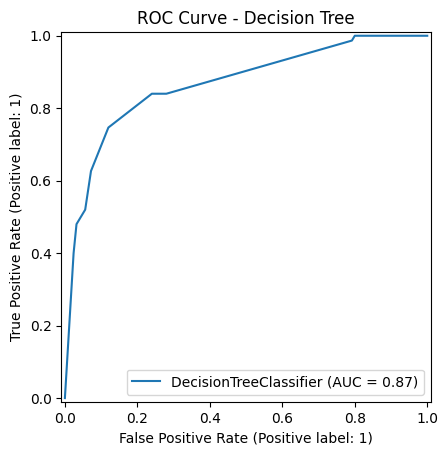

F1 Score (KNN): 0.7066666666666667


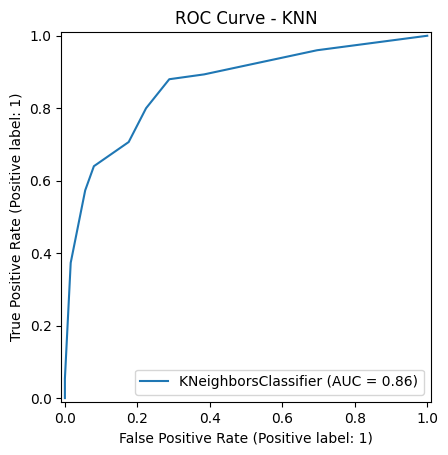

In [43]:
from sklearn.metrics import f1_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_val_pred_dt = best_dt.predict(X_val)
f1_dt = f1_score(y_val, y_val_pred_dt)
print(f"F1 Score (Decision Tree): {f1_dt}")

RocCurveDisplay.from_estimator(best_dt, X_val, y_val)
plt.title('ROC Curve - Decision Tree')
plt.show()

y_val_pred_knn = best_knn.predict(X_val)
f1_knn = f1_score(y_val, y_val_pred_knn)
print(f"F1 Score (KNN): {f1_knn}")

RocCurveDisplay.from_estimator(best_knn, X_val, y_val)
plt.title('ROC Curve - KNN')
plt.show()

In [44]:
print(evaluation_data.columns)
print('+++++')
print(evaluation_data.dtypes)

Index(['ID', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'home.dest'],
      dtype='object')
+++++
ID             int64
pclass         int64
name          object
sex           object
age          float64
sibsp          int64
parch          int64
ticket        object
fare         float64
cabin         object
embarked      object
home.dest     object
dtype: object


In [45]:
ids = evaluation_data['ID']

num_imputer = SimpleImputer(strategy='median')
evaluation_data[['age', 'fare']] = num_imputer.fit_transform(evaluation_data[['age', 'fare']])
evaluation_data[['age', 'fare']] = scaler.transform(evaluation_data[['age', 'fare']])

evaluation_data = encode_data(evaluation_data)
evaluation_data = evaluation_data[X_train.columns]
print(evaluation_data.columns)
print('+++++')
print(evaluation_data.dtypes)

Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q',
       'embarked_S'],
      dtype='object')
+++++
pclass          int64
sex             int64
age           float64
sibsp           int64
parch           int64
fare          float64
embarked_Q       bool
embarked_S       bool
dtype: object


In [48]:
# Final model
final_model = best_dt if f1_dt > f1_knn else best_knn
evaluation_pred = final_model.predict(evaluation_data)

results = pd.DataFrame({
    'ID': ids,
    'survived': evaluation_pred
})
results.to_csv('results.csv', index=False)

In [49]:
print(results['survived'].sum())

118
